<a href="https://colab.research.google.com/github/vaishnavi-08-reddy/growfinix_intenship/blob/main/task2_titanic_survival_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset loaded successfully.

Data Info & Shape 
Dataset Shape: (891, 15)

Data Types:
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

Missing Values per Column:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


Handling Missing Values
Missing values remaining: 0

--- Step 4: Encoding Categorical Data ---
      sex  sex_code embarked  embarked_code
0    male         1        S              2
1  female         0        C

/tmp/ipykernel_1888/3838155426.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="sex", y="survived", data=df, errorbar=None, palette="muted")


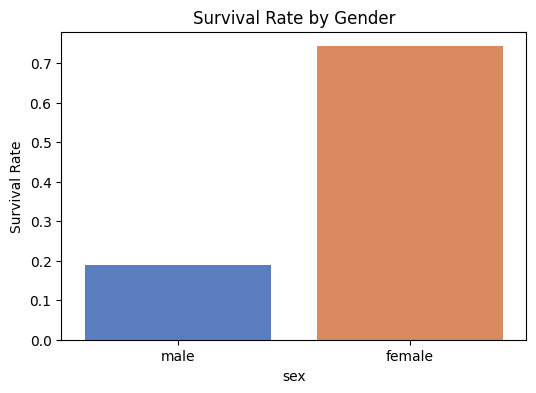

/tmp/ipykernel_1888/3838155426.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="class", y="survived", data=df, errorbar=None, palette="magma")


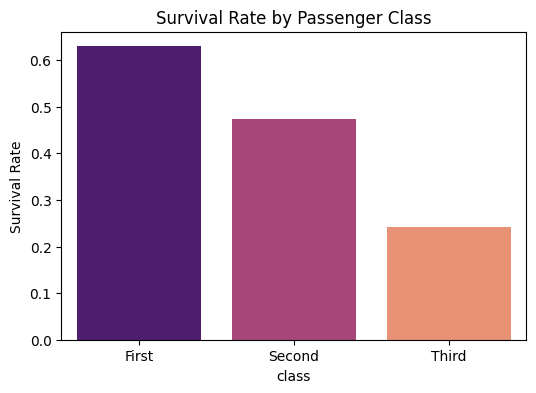

/tmp/ipykernel_1888/3838155426.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


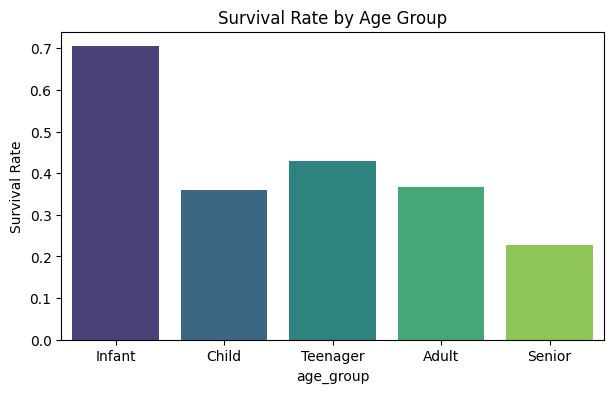

--- Bonus Step: Creating Interactive Plotly Charts ---


--- Step 6: Family Size & Fare Impact Analysis ---


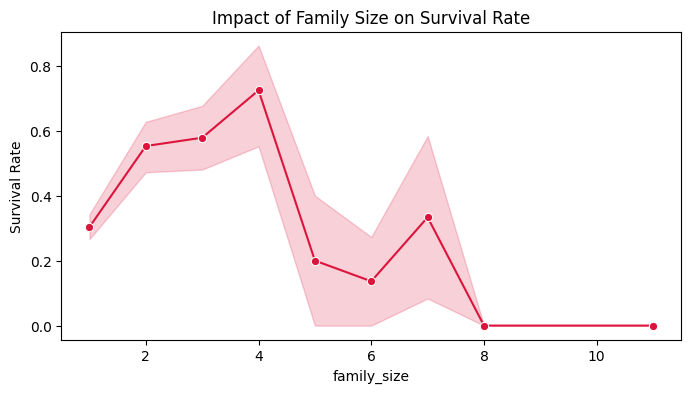

/tmp/ipykernel_1888/3838155426.py:115: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




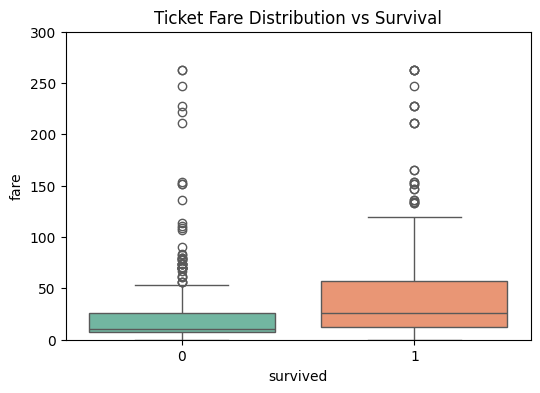

Pivot Tables & Aggregations
Groupby Summary (Survival Rate by Class and Sex):
               survived
class  sex             
First  female  0.968085
       male    0.368852
Second female  0.921053
       male    0.157407
Third  female  0.500000
       male    0.135447

Pivot Table Summary (Average Fare & Survival Rate by Embark Town & Class):
                   fare                        survived                    
class             First     Second      Third     First    Second     Third
embark_town                                                                
Cherbourg    104.718529  25.358335  11.214083  0.694118  0.529412  0.378788
Queenstown    90.000000  12.350000  11.183393  0.500000  0.666667  0.375000
Southampton   70.514244  20.327439  14.644083  0.589147  0.463415  0.189802 

Exporting Processed Data
Cleaned dataset successfully saved locally in Colab environment.


/tmp/ipykernel_1888/3838155426.py:124: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_1888/3838155426.py:127: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior



In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import seaborn as sns
from google.colab import files

# Creating a folder in Colab to store your charts
os.makedirs("charts", exist_ok=True)

#  Loading Titanic dataset
df = sns.load_dataset("titanic")
print("Dataset loaded successfully.\n")

# to Check data types, missing values, and shape
print("Data Info & Shape ")
print(f"Dataset Shape: {df.shape}")
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values per Column:")
print(df.isnull().sum())
print("\n")

# Filling or droping missing data (like Age or Cabin)
print("Handling Missing Values")
# Filling missing age values with the median age
df["age"] = df["age"].fillna(df["age"].median())

# 'deck' (corresponds to Cabin) has too many missing values; we will drop it
df = df.drop(columns=["deck"])

# TO  tFill remaining minor missing values in 'embarked' and 'embark_town' with mode
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])
df["embark_town"] = df["embark_town"].fillna(df["embark_town"].mode()[0])

print(f"Missing values remaining: {df.isnull().sum().sum()}\n")

# Converting 'Sex' and 'Embarked' into numeric code
print("--- Step 4: Encoding Categorical Data ---")
df["sex_code"] = df["sex"].astype("category").cat.codes
df["embarked_code"] = df["embarked"].astype("category").cat.codes
print(df[["sex", "sex_code", "embarked", "embarked_code"]].head(), "\n")

# Creating plots for survival vs gender/class/age group
print("Generating Static Plots (Seaborn/Matplotlib)")

# Plot A: Survival vs Gender
plt.figure(figsize=(6, 4))
sns.barplot(x="sex", y="survived", data=df, errorbar=None, palette="muted")
plt.title("Survival Rate by Gender")
plt.ylabel("Survival Rate")
plt.savefig("charts/survival_vs_gender.png")
plt.show()  # Displays directly in your Colab output

# Plot B: Survival vs Class
plt.figure(figsize=(6, 4))
sns.barplot(x="class", y="survived", data=df, errorbar=None, palette="magma")
plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Rate")
plt.savefig("charts/survival_vs_class.png")
plt.show()

# Plot C: Survival vs Age Group
age_labels = ["Infant", "Child", "Teenager", "Adult", "Senior"]
df["age_group"] = pd.cut(
    df["age"], bins=[0, 5, 12, 18, 60, 100], labels=age_labels
)

plt.figure(figsize=(7, 4))
sns.barplot(
    x="age_group", y="survived", data=df, errorbar=None, palette="viridis"
)
plt.title("Survival Rate by Age Group")
plt.ylabel("Survival Rate")
plt.savefig("charts/survival_vs_age_group.png")
plt.show()

# Add interactive plots using Plotly
print("--- Bonus Step: Creating Interactive Plotly Charts ---")

# Configure Plotly to render flawlessly inside Google Colab cells
import plotly.io as pio

pio.renderers.default = "colab"

# Interactive Multi-dimensional plot
fig_interactive = px.histogram(
    df,
    x="age",
    color="survived",
    facet_col="class",
    facet_row="sex",
    barmode="group",
    title="Interactive Breakdown: Survival by Age, Class, and Gender",
    labels={"survived": "Survived (1=Yes, 0=No)"},
    template="plotly_dark",
)
fig_interactive.show()
fig_interactive.write_html("charts/interactive_survival_analysis.html")

# To Show how family size or ticket fare affected survival
print("--- Step 6: Family Size & Fare Impact Analysis ---")
df["family_size"] = df["sibsp"] + df["parch"] + 1

plt.figure(figsize=(8, 4))
sns.lineplot(
    x="family_size", y="survived", data=df, marker="o", color="crimson"
)
plt.title("Impact of Family Size on Survival Rate")
plt.ylabel("Survival Rate")
plt.savefig("charts/survival_vs_family_size.png")
plt.show()

plt.figure(figsize=(6, 4))
sns.boxplot(x="survived", y="fare", data=df, palette="Set2")
plt.title("Ticket Fare Distribution vs Survival")
plt.ylim(0, 300)
plt.savefig("charts/survival_vs_fare.png")
plt.show()

# Use groupby() and pivot_table() for deeper insights
print("Pivot Tables & Aggregations")
print("Groupby Summary (Survival Rate by Class and Sex):")
groupby_insight = df.groupby(["class", "sex"])[["survived"]].mean()
print(groupby_insight)
print("\nPivot Table Summary (Average Fare & Survival Rate by Embark Town & Class):")
pivot_insight = df.pivot_table(
    values=["survived", "fare"], index="embark_town", columns="class", aggfunc="mean"
)
print(pivot_insight, "\n")

# Export cleaned dataset
print("Exporting Processed Data")
df.to_csv("cleaned_titanic_dataset.csv", index=False)
print("Cleaned dataset successfully saved locally in Colab environment.")

### Key Analytical Conclusions
# *Gender: The "Women and children first" protocol is strongly reflected in the data. Females had a significantly higher survival rate across all passenger classes.
# *Socioeconomic Status (Class): Passenger class was a decisive survival factor. First-class passengers achieved the highest survival probability, whereas third-class passengers bore the highest casualty rate.
# *Fare Price:* Higher ticket fares correlate tightly with increased survival rates, further reinforcing the class divide impact.
# *Family Size:* Traveling alone or with a very large family group (5+ members) resulted in lower survival rates. Traveling with a small, manageable family size (2-4 members) gave passengers the highest likelihood of surviving.
#